# Circuits for Lesson 8 of the Tutorial

The 8 entries the Symbulator app lists under *Built-in Examples › Circuits for Lesson 8 of the Tutorial*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# !pip install symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.16'

## 1. AS7's Example 11.5 (maximum average power)

Find the load impedance that maximises the average power drawn from the circuit, and that maximum power. The load that draws the most power is the conjugate of zeq. Version 9 has no separate apmax: in AC, pmax is already the average maximum power.

![The circuit of AS7's Example 11.5 (maximum average power)](https://learn.symbulator.com/assets/circuit/as7e1105.png)

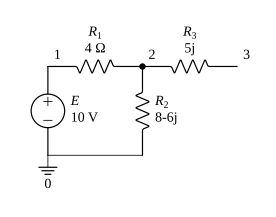

In [3]:
c1 = '''
e,1,0,10
r1,1,2,4
r2,2,0,8-6j
r3,2,3,5j
'''
draw(c1)

In [4]:
r1 = th(c1, '3', '0', domain='ac', omega='omega')
r1

TheveninResult(domain='ac', vth=22/3 - 4*I/3, ino=140/257 - 330*I/257, zeq=44/15 + 67*I/15, pmax=625/264)

## 2. AS7's Example 11.10 (power factor)

Find the power factor of the circuit as seen by the source, and the average power the source delivers — the Evaluate line, -pe: 125.4 W. The values are RMS, so the RMS setting is on. The power factor comes from the pf mini-tool given the source's name, e: 0.97342 leading -- a source is read on the power it delivers, so the reading is of the circuit it sees. Given the complex power se instead, it reads 0.97342 lagging -- the word for the power the source consumes, which is the opposite of what it delivers.

![The circuit of AS7's Example 11.10 (power factor)](https://learn.symbulator.com/assets/circuit/as7e1110.png)

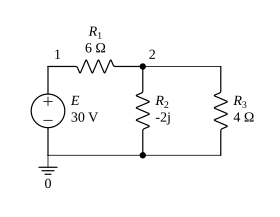

In [5]:
c2 = '''
e,1,0,30
r1,1,2,6
r2,2,0,-2j
r3,2,0,4
'''
draw(c2)

In [6]:
r2 = ac(c2, omega='omega', use_rms=True)
r2.rounded(5)

Result(domain='ac')
  ap_e = -125.41
  ap_r1 = 110.66
  ap_r2 = 0
  ap_r3 = 14.754
  i_e = -4.1803 - 0.98361*I
  i_r1 = 4.1803 + 0.98361*I
  i_r2 = 2.9508 + 2.459*I
  i_r3 = 1.2295 - 1.4754*I
  p_e = -125.41
  p_r1 = 110.66
  p_r2 = 0
  p_r3 = 14.754
  q_e = 29.508
  q_r1 = 0
  q_r2 = -29.508
  q_r3 = 0
  s_e = -125.41 + 29.508*I
  s_r1 = 110.66
  s_r2 = -29.508*I
  s_r3 = 14.754
  v_1 = 30
  v_2 = 4.918 - 5.9016*I
  v_e = 30
  v_r1 = 25.082 + 5.9016*I
  v_r2 = 4.918 - 5.9016*I
  v_r3 = 4.918 - 5.9016*I
  z_e = 6.8 - 1.6*I

In [7]:
evaluate(r2, '-pe')

7650/61

## 3. AS7's Example 11.13 (complex power)

Find the real and reactive power delivered by the source (the Evaluate line, -se) and absorbed by the transmission line (sr1) and the load (sr2). RMS values throughout.

![The circuit of AS7's Example 11.13 (complex power)](https://learn.symbulator.com/assets/circuit/as7e1113.png)

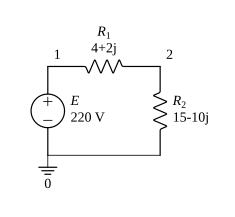

In [8]:
c3 = '''
e,1,0,220
r1,1,2,4+2j
r2,2,0,15-10j
'''
draw(c3)

In [9]:
r3 = ac(c3, omega='omega', use_rms=True)
r3.rounded(5)

Result(domain='ac')
  ap_e = -2163.8
  ap_r1 = 455.53
  ap_r2 = 1708.2
  i_e = -9.8353 - 4.1412*I
  i_r1 = 9.8353 + 4.1412*I
  i_r2 = 9.8353 + 4.1412*I
  p_e = -2163.8
  p_r1 = 455.53
  p_r2 = 1708.2
  q_e = 911.06
  q_r1 = 227.76
  q_r2 = -1138.8
  s_e = -2163.8 + 911.06*I
  s_r1 = 455.53 + 227.76*I
  s_r2 = 1708.2 - 1138.8*I
  v_1 = 220
  v_2 = 188.94 - 36.235*I
  v_e = 220
  v_r1 = 31.059 + 36.235*I
  v_r2 = 188.94 - 36.235*I
  z_e = 19.0 - 8.0*I

In [10]:
evaluate(r3, '-se')

36784/17 - 15488*I/17

## 4. AS7's Practice Problem 11.10

Find the power factor of the circuit as seen by the source, and the average power it supplies — the Evaluate line, -pe: 2007.1 W. pf given the source's name, e, reads 0.93595 lagging.

![The circuit of AS7's Practice Problem 11.10](https://learn.symbulator.com/assets/circuit/as7pp1110.png)

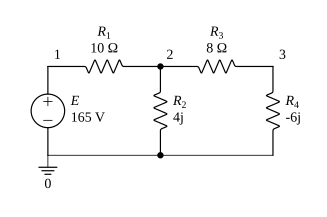

In [11]:
c4 = '''
e,1,0,165
r1,1,2,10
r2,2,0,4j
r3,2,3,8
r4,3,0,-6j
'''
draw(c4)

In [12]:
r4 = ac(c4, omega='omega', use_rms=True)
r4.rounded(5)

Result(domain='ac')
  ap_e = -2007.1
  ap_r1 = 1689.1
  ap_r2 = 0
  ap_r3 = 317.96
  ap_r4 = 0
  i_e = -12.164 + 4.5766*I
  i_r1 = 12.164 - 4.5766*I
  i_r2 = 11.442 - 10.839*I
  i_r3 = 0.72263 + 6.2628*I
  i_r4 = 0.72263 + 6.2628*I
  p_e = -2007.1
  p_r1 = 1689.1
  p_r2 = 0
  p_r3 = 317.96
  p_r4 = 0
  q_e = -755.15
  q_r1 = 0
  q_r2 = 993.61
  q_r3 = 0
  q_r4 = -238.47
  s_e = -2007.1 - 755.15*I
  s_r1 = 1689.1
  s_r2 = 993.61*I
  s_r3 = 317.96
  s_r4 = -238.47*I
  v_1 = 165
  v_2 = 43.358 + 45.766*I
  v_3 = 37.577 - 4.3358*I
  v_e = 165
  v_r1 = 121.64 - 45.766*I
  v_r2 = 43.358 + 45.766*I
  v_r3 = 5.781 + 50.102*I
  v_r4 = 37.577 - 4.3358*I
  z_e = 11.882 + 4.4706*I

In [13]:
evaluate(r4, '-pe')

549945/274

## 5. AS7's Problem 11.97 (transmission line)

A power transmission system, modelled as line, load and return path in series: find the average power absorbed by the load — the rl block's power consumed line, 573.2 W.

![The circuit of AS7's Problem 11.97 (transmission line)](https://learn.symbulator.com/assets/circuit/as7p1197.png)

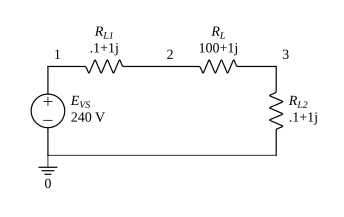

In [14]:
c5 = '''
evs,1,0,240
rl1,1,2,.1+1j
rl,2,3,100+1j
rl2,3,0,.1+1j
'''
draw(c5)

In [15]:
r5 = ac(c5, omega='omega', use_rms=True)
r5.rounded(5)

Result(domain='ac')
  ap_evs = -574.34
  ap_rl = 573.19
  ap_rl1 = 0.57319
  ap_rl2 = 0.57319
  i_evs = -2.3931 + 0.071649*I
  i_rl = 2.3931 - 0.071649*I
  i_rl1 = 2.3931 - 0.071649*I
  i_rl2 = 2.3931 - 0.071649*I
  p_evs = -574.34
  p_rl = 573.19
  p_rl1 = 0.57319
  p_rl2 = 0.57319
  q_evs = -17.196
  q_rl = 5.7319
  q_rl1 = 5.7319
  q_rl2 = 5.7319
  s_evs = -574.34 - 17.196*I
  s_rl = 573.19 + 5.7319*I
  s_rl1 = 0.57319 + 5.7319*I
  s_rl2 = 0.57319 + 5.7319*I
  v_1 = 240.00
  v_2 = 239.69 - 2.3859*I
  v_3 = 0.31096 + 2.3859*I
  v_evs = 240.00
  v_rl = 239.38 - 4.7718*I
  v_rl1 = 0.31096 + 2.3859*I
  v_rl2 = 0.31096 + 2.3859*I
  z_evs = 100.2 + 3.0*I

## 6. AS7's Problem 11.75 (a and b, the power system)

Parts (a) and (b): find the total complex power delivered (the Evaluate line, -se) and the power factor. pf given the source's name, e, reads 0.99805 leading, which is what makes part (c) come out the way it does.

![The circuit of AS7's Problem 11.75 (a and b, the power system)](https://learn.symbulator.com/assets/circuit/as7p1175.png)

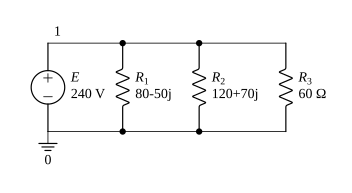

In [16]:
c6 = '''
e,1,0,240
r1,1,0,80-50j
r2,1,0,120+70j
r3,1,0,60
'''
draw(c6)

In [17]:
r6 = ac(c6, omega='omega', use_rms=True)
r6.rounded(5)

Result(domain='ac')
  ap_e = -1835.9
  ap_r1 = 517.75
  ap_r2 = 358.13
  ap_r3 = 960
  i_e = -7.6495 - 0.47785*I
  i_r1 = 2.1573 + 1.3483*I
  i_r2 = 1.4922 - 0.87047*I
  i_r3 = 4
  p_e = -1835.9
  p_r1 = 517.75
  p_r2 = 358.13
  p_r3 = 960
  q_e = 114.68
  q_r1 = -323.60
  q_r2 = 208.91
  q_r3 = 0
  s_e = -1835.9 + 114.68*I
  s_r1 = 517.75 - 323.6*I
  s_r2 = 358.13 + 208.91*I
  s_r3 = 960
  v_1 = 240
  v_e = 240
  v_r1 = 240
  v_r2 = 240
  v_r3 = 240
  z_e = 31.253 - 1.9523*I

In [18]:
evaluate(r6, '-se')

31535040/17177 - 1969920*I/17177

## 7. AS7's Problem 11.75 (c, trying a capacitor)

Part (c): solve im(se) = 0 for the parallel capacitance x, at 50 Hz. The answer comes back negative. No positive capacitance can work: part (b) showed the load is already leading, so a capacitor pushes it further the wrong way. Probably why the textbook gives no number here.

![The circuit of AS7's Problem 11.75 (c, trying a capacitor)](https://learn.symbulator.com/assets/circuit/as7p1175.png)

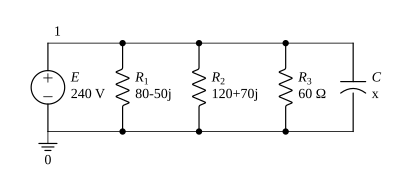

In [19]:
c7 = '''
e,1,0,240
r1,1,0,80-50j
r2,1,0,120+70j
r3,1,0,60
c,1,0,x
'''
draw(c7)

In [20]:
r7 = ac(c7, omega=sp.sympify('2*pi*50'), use_rms=True)
r7.rounded(5)

Result(domain='ac')
  ap_e = 1.8096e+7*im(x) - 1835.9
  ap_r1 = 517.75
  ap_r2 = 358.13
  ap_r3 = 960
  i_c = 75398.0*I*x
  i_e = -75398.0*I*x - 7.6495 - 0.47785*I
  i_r1 = 2.1573 + 1.3483*I
  i_r2 = 1.4922 - 0.87047*I
  i_r3 = 4
  p_e = 1.8096e+7*im(x) - 1835.9
  p_r1 = 517.75
  p_r2 = 358.13
  p_r3 = 960
  q_e = 1.8096e+7*re(x) + 114.68
  q_r1 = -323.60
  q_r2 = 208.91
  q_r3 = 0
  s_c = -1.8096e+7*I*conjugate(x)
  s_e = 1.8096e+7*I*conjugate(x) - 1835.9 + 114.68*I
  s_r1 = 517.75 - 323.6*I
  s_r2 = 358.13 + 208.91*I
  s_r3 = 960
  v_1 = 240
  v_c = 240
  v_e = 240
  v_r1 = 240
  v_r2 = 240
  v_r3 = 240
  z_e = 1.0306e+6/(3.2378e+8*I*x + 32849.0 + 2052.0*I)

In [21]:
solve(r7, ['im(se) = 0'], ['x'], real_only=True)

[{'x': -171/(8588500*pi)}]

## 8. AS7's Problem 11.75 (c, an inductor instead)

The same solve with an inductor in place of the capacitor: x = 1.5987 H. Positive, and putting it back in as the inductor's value brings the power factor to 1.

![The circuit of AS7's Problem 11.75 (c, an inductor instead)](https://learn.symbulator.com/assets/circuit/as7p1175.png)

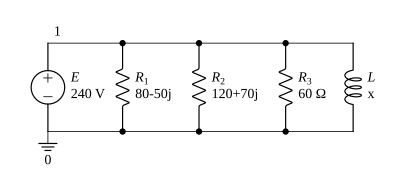

In [22]:
c8 = '''
e,1,0,240
r1,1,0,80-50j
r2,1,0,120+70j
r3,1,0,60
l,1,0,x
'''
draw(c8)

In [23]:
r8 = ac(c8, omega=sp.sympify('2*pi*50'), use_rms=True)
r8.rounded(5)

Result(domain='ac')
  ap_e = 0.003558*(-5.1599e+5*re(x)**2 - 5.1599e+5*im(x)**2 + 51531.0*im(x))/(re(x)**2 + im(x)**2)
  ap_r1 = 517.75
  ap_r2 = 358.13
  ap_r3 = 960
  i_e = -7.6495 - 0.47785*I + 0.76394*I/x
  i_l = -0.76394*I/x
  i_r1 = 2.1573 + 1.3483*I
  i_r2 = 1.4922 - 0.87047*I
  i_r3 = 4
  p_e = 0.003558*(-5.1599e+5*re(x)**2 - 5.1599e+5*im(x)**2 + 51531.0*im(x))/(re(x)**2 + im(x)**2)
  p_r1 = 517.75
  p_r2 = 358.13
  p_r3 = 960
  q_e = 0.010674*(10744.0*re(x)**2 - 17177.0*re(x) + 10744.0*im(x)**2)/(re(x)**2 + im(x)**2)
  q_r1 = -323.60
  q_r2 = 208.91
  q_r3 = 0
  s_e = -1835.9 + 114.68*I - 183.35*I/conjugate(x)
  s_l = 183.35*I/conjugate(x)
  s_r1 = 517.75 - 323.6*I
  s_r2 = 358.13 + 208.91*I
  s_r3 = 960
  v_1 = 240
  v_e = 240
  v_l = 240
  v_r1 = 240
  v_r2 = 240
  v_r3 = 240
  z_e = 1.6189e+7*x/(x*(5.1599e+5 + 32233.0*I) - 51531.0*I)

In [24]:
solve(r8, ['im(se) = 0'], ['x'], real_only=True)

[{'x': 17177/(3420*pi)}]